In [ ]:
## Imports
import numpy as np
from scipy.linalg import inv
import matplotlib.pyplot as plt
import matplotlib
from gibbs_sampling import (
    SampleMultivariate,
    GaussianSampleMultivariate,
    StudenttSampleMultivariate,
    BimodalSampleMultivariate,
    HeavisideSampleMultivariate,
)
from sklearn.gaussian_process.kernels import  RBF

matplotlib.rcParams["font.family"] = "STIXGeneral"
matplotlib.rc("text", usetex=True)

In [ ]:
## Setup problem

def real_function(x: np.ndarray):
    return np.sin(2 * np.pi * x)


def kernel(x: np.ndarray, y: np.ndarray | None = None, length_scale=0.2, nu=2.5):
    return RBF(length_scale=length_scale)(x, y)

training_X = np.array([[0.1], [0.35], [0.67], [0.83]])
training_y = real_function(training_X)

In [3]:
## Generally useful calculations

class NothingScaler:
    def __init__(self) -> None:
        pass

    def inverse_transform(self, x):
        return x


y_scaler = NothingScaler()

Sigma_yy = kernel(training_X)
inv_Sigma_yy = inv(Sigma_yy)

testing_X = np.linspace(0, 1, 100).reshape(-1, 1)

Sigma_ff = kernel(testing_X)
Sigma_fy = kernel(testing_X, training_X)
Sigma_fy_dot_inv_Sigma_yy_dot_y = Sigma_fy @ inv_Sigma_yy @ training_y
schur_Sigma_yy = Sigma_ff - Sigma_fy @ inv_Sigma_yy @ Sigma_fy.T
y_squared = (training_y.reshape(1, -1) @ inv_Sigma_yy @ training_y).flatten()[0]

distribution_expectation = Sigma_fy_dot_inv_Sigma_yy_dot_y.copy()
distribution_covariance = schur_Sigma_yy.copy()

In [4]:
## Parameters for distributions

nu = 2
heaviside_n = 8
assert heaviside_n > y_squared, f"{heaviside_n}, {y_squared}"
bimodal_n = 4.1
list_of_distributions: dict[str, SampleMultivariate] = {
    "Gaussian": GaussianSampleMultivariate(
        distribution_expectation, distribution_covariance
    ),
    "Student \emph{t}": StudenttSampleMultivariate(
        distribution_expectation,
        distribution_covariance * (nu + y_squared) / (nu + len(training_X)),
        nu + len(training_X),
    ),
    "Bimodal": BimodalSampleMultivariate(
        distribution_expectation,
        distribution_covariance,
        bimodal_n + y_squared - len(training_X),
    ),
    "Heaviside": HeavisideSampleMultivariate(
        distribution_expectation,
        distribution_covariance
        * (heaviside_n - y_squared)
        / (heaviside_n - len(training_X)),
        heaviside_n - len(training_X),
    ),
}


Running  Gaussian


Running  Student \emph{t}


Running  Bimodal


Running  Heaviside



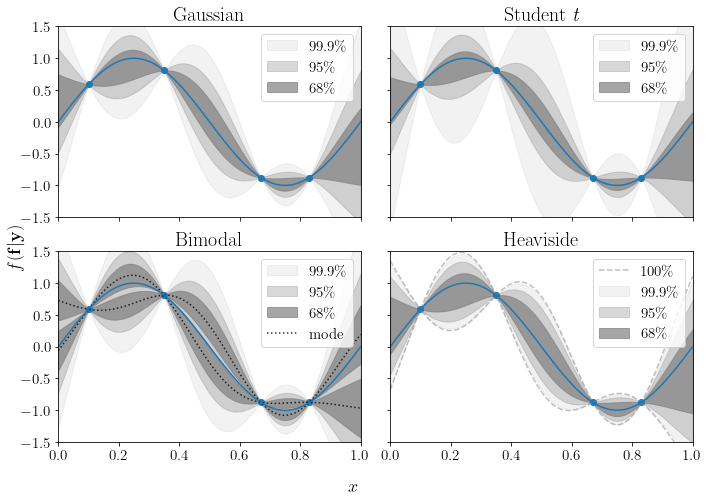

In [5]:
## Plot
fig, axes = plt.subplots(
    nrows=2, ncols=2, figsize=(10, 7), sharex=True, sharey=True
)

for ax, (name, sampler) in zip(axes.flatten(), list_of_distributions.items()):
    print("")
    print("Running ", name)
    print("")
    ax.set_title(name, fontsize=20)
    ax.tick_params(axis="both", which="major", labelsize=15)

    expectation = sampler.μ

    if name == "Heaviside":
        quantile_100 = sampler.quantiles(1)
        ax.plot(
            testing_X.reshape(-1),
            y_scaler.inverse_transform(quantile_100[:, 0].reshape(-1, 1)).flatten(),
            color="grey",
            alpha=0.5,
            ls="--",
        )
        ax.plot(
            testing_X.reshape(-1),
            y_scaler.inverse_transform(quantile_100[:, 1].reshape(-1, 1)).flatten(),
            color="grey",
            alpha=0.5,
            ls="--",
            label="100\%",
        )

    for quantile, alpha, precision in zip(
        [0.999, 0.95, 0.68], [0.1, 0.3, 0.7], [1, 0, 0]
    ):
        quantile_values = sampler.quantiles(quantile)
        ax.fill_between(
            testing_X.reshape(-1),
            y_scaler.inverse_transform(
                quantile_values[:, 0].reshape(-1, 1)
            ).flatten(),
            y_scaler.inverse_transform(
                quantile_values[:, 1].reshape(-1, 1)
            ).flatten(),
            color="grey",
            alpha=alpha,
            label=f"{quantile*100:.{precision}f}\%",
        )
        if quantile_values.shape[1] > 2:
            ax.fill_between(
                testing_X.reshape(-1),
                y_scaler.inverse_transform(
                    quantile_values[:, 2].reshape(-1, 1)
                ).flatten(),
                y_scaler.inverse_transform(
                    quantile_values[:, 3].reshape(-1, 1)
                ).flatten(),
                color="grey",
                alpha=alpha,
            )
    if name == "Bimodal":
        ax.plot(
            testing_X.reshape(-1),
            y_scaler.inverse_transform(
                (sampler.μ.reshape(-1) - sampler.mode_offset).reshape(-1, 1)
            ).flatten(),
            color="black",
            alpha=0.8,
            ls=":",
            label="mode",
        )
        ax.plot(
            testing_X.reshape(-1),
            y_scaler.inverse_transform(
                (sampler.μ.reshape(-1) + sampler.mode_offset).reshape(-1, 1)
            ).flatten(),
            color="black",
            alpha=0.8,
            ls=":",
        )

    ax.scatter(
        training_X.reshape(-1),
        y_scaler.inverse_transform(training_y.reshape(-1, 1)).flatten(),
    )
    ax.plot(
        testing_X.reshape(-1),
        real_function(testing_X),
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(-1.5, 1.5)
    ax.legend(loc="upper right", fontsize=15)

fig.supxlabel("$x$", fontsize=18)
fig.supylabel("$f(\mathbf{f}|\mathbf{y})$", fontsize=18)

plt.tight_layout()
plt.show()